In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("CreditScoring.csv")

In [3]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [6]:
# The original R script has the section for guides on how to clean data.
# https://github.com/gastonstat/CreditScoring/blob/master/Part1_CredScoring_Processing.R
# Also, there is an information about which columns are categorical and types of categories.
# In R indices start with 1.

In [7]:
status_values = {
    1: "ok",
    2: "default",
    0: "unk"
}

df.status = df.status.map(status_values)

home_values = {
    1: "rent",
    2: "owner",
    3: "private",
    4: "ignore",
    5: "parents",
    6: "other",
    0: "unk"
}

df.home = df.home.map(home_values)

marital_values = {
    1: "single",
    2: "married",
    3: "widow",
    4: "separated",
    5: "divorced",
    0: "unk"
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: "no",
    2: "yes",
    0: "unk"
}

df.records = df.records.map(records_values)

job_values = {
    1: "fixed",
    2: "partime",
    3: "freelance",
    4: "others",
    0: "unk"
}

df.job = df.job.map(job_values)

In [8]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92,0,0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75,3000,600,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90,3500,0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140,0,0,550,550


In [9]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [10]:
# As we can see the columns "income", "assets", "debt" have the max value of 999999999 which is considered as missing values.

In [11]:
value_to_replace = df.income.max()

In [12]:
value_to_replace

np.int64(99999999)

In [13]:
# Using the eq func that returns the column names containing the specific value
columns_with_missing = df.columns[df.eq(value_to_replace).any()].tolist()
for column in columns_with_missing:
    df[column] = df[column].replace(to_replace=value_to_replace, value=np.nan)

In [14]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [15]:
# Unknown values in status are not helping and can brick model. Remove the unknown values.
df = df[df.status != "unk"].reset_index(drop=True)

In [16]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107.0,0.0,0.0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4449,default,1,rent,60,39,married,no,fixed,69,92.0,0.0,0.0,900,1020
4450,ok,22,owner,60,46,married,no,fixed,60,75.0,3000.0,600.0,950,1263
4451,default,0,owner,24,37,married,no,partime,60,90.0,3500.0,0.0,500,963
4452,ok,0,rent,48,23,single,no,freelance,49,140.0,0.0,0.0,550,550


In [17]:
from sklearn.model_selection import train_test_split

# Split 60/20/20
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [18]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [19]:
y_train = (df_train.status == "default").astype("int").values
y_val = (df_val.status == "default").astype("int").values
y_test = (df_test.status == "default").astype("int").values

In [20]:
del df_train["status"]
del df_val["status"]
del df_test["status"]

In [21]:
# Decision trees are models, with logic similar to a bunch of if-else statements
def _asses_risk(client: dict) -> str:
    if client.get("records") == "yes":
        if client.get("job") == "parttime":
            return "default"
        else:
            return "ok"
    else:
        if client.get("assets") > 6000:
            return "ok"
        else:
            return "default"

In [22]:
# "Predict" clients from train dataset
risk = {}
for client in range(len(df_train.index)):
    risk.update({client: _asses_risk(df_train.iloc[client].to_dict())})
risk

{0: 'ok',
 1: 'ok',
 2: 'default',
 3: 'default',
 4: 'default',
 5: 'ok',
 6: 'default',
 7: 'default',
 8: 'default',
 9: 'default',
 10: 'ok',
 11: 'default',
 12: 'default',
 13: 'default',
 14: 'default',
 15: 'default',
 16: 'default',
 17: 'default',
 18: 'default',
 19: 'default',
 20: 'default',
 21: 'default',
 22: 'default',
 23: 'default',
 24: 'ok',
 25: 'default',
 26: 'default',
 27: 'default',
 28: 'ok',
 29: 'default',
 30: 'ok',
 31: 'ok',
 32: 'default',
 33: 'default',
 34: 'default',
 35: 'default',
 36: 'ok',
 37: 'ok',
 38: 'default',
 39: 'default',
 40: 'ok',
 41: 'default',
 42: 'default',
 43: 'default',
 44: 'default',
 45: 'default',
 46: 'default',
 47: 'ok',
 48: 'default',
 49: 'ok',
 50: 'default',
 51: 'ok',
 52: 'ok',
 53: 'default',
 54: 'default',
 55: 'default',
 56: 'default',
 57: 'default',
 58: 'default',
 59: 'default',
 60: 'default',
 61: 'ok',
 62: 'default',
 63: 'ok',
 64: 'ok',
 65: 'ok',
 66: 'ok',
 67: 'ok',
 68: 'default',
 69: 'defau

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [24]:
train_dicts = df_train.fillna(0).to_dict(orient="records")

In [25]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)

In [26]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [27]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [28]:
val_dicts = df_val.fillna(0).to_dict(orient="records")
X_val = dv.transform(val_dicts)

In [29]:
y_pred = dt.predict_proba(X_val)

In [30]:
y_pred = y_pred[:, 1]

In [31]:
roc_auc_score(y_val, y_pred)

0.6524515027487829

In [32]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

1.0

In [33]:
# When the model is so drastically different this is called "overfitting".
# This is happening because model "memorizes" data. And when it sees a new sample, that is unknown for model, the results are sad.
# So the model creates rules just for one sample, that will not be used in any other prediction.
# The root of the problem is that the tree, which was created, is very deep.
# The solution is to restrict the depth of the tree, for example depth = 3.

In [34]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [35]:
y_pred = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred)

0.7389079944782155

In [36]:
# The score improved drastically

In [37]:
y_pred = dt.predict_proba(X_train)[:, 1]
roc_auc_score(y_train, y_pred)

0.7761016984958594

In [38]:
# Now the ratio between "ideal" dataset and validation dataset is not very big.

In [39]:
from sklearn.tree import export_text

# Visualize the tree
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=no <= 0.50
|   |--- seniority <= 6.50
|   |   |--- amount <= 862.50
|   |   |   |--- class: 0
|   |   |--- amount >  862.50
|   |   |   |--- class: 1
|   |--- seniority >  6.50
|   |   |--- income <= 103.50
|   |   |   |--- class: 1
|   |   |--- income >  103.50
|   |   |   |--- class: 0
|--- records=no >  0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- class: 0
|   |   |--- income >  74.50
|   |   |   |--- class: 0
|   |--- job=partime >  0.50
|   |   |--- assets <= 8750.00
|   |   |   |--- class: 1
|   |   |--- assets >  8750.00
|   |   |   |--- class: 0



In [40]:
# This is "infinite" tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- records=yes <= 0.50
|   |--- job=partime <= 0.50
|   |   |--- income <= 74.50
|   |   |   |--- assets <= 4250.00
|   |   |   |   |--- income <= 20.00
|   |   |   |   |   |--- seniority <= 1.50
|   |   |   |   |   |   |--- home=parents <= 0.50
|   |   |   |   |   |   |   |--- seniority <= 0.50
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- seniority >  0.50
|   |   |   |   |   |   |   |   |--- price <= 1457.50
|   |   |   |   |   |   |   |   |   |--- expenses <= 55.00
|   |   |   |   |   |   |   |   |   |   |--- home=other <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |   |   |--- home=other >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- expenses >  55.00
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- price >  1457.50
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- h

In [41]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [42]:
# Decision tree - example with small dataset

In [43]:
data = [
    [8000, "default"],
    [2000, "default"],
    [0, "default"],
    [5000, "ok"],
    [5000, "ok"],
    [4000, "ok"],
    [9000, "ok"],
    [3000, "default"],
]

df_example = pd.DataFrame(data, columns=["assets", "status"])
df_example

,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


In [44]:
# Condition - assets > T (T - threshold)
# The task is to find the best T value
# Node condition - o
# Split - the decision
# Leaf - the non-depth decision
# leaf-left <- o -> leaf-right   <<- this is called split, because we are splitting the dataset into two parts
# Right - True
# Left - False

In [45]:
df_example.sort_values("assets")

,assets,status
2,0,default
1,2000,default
7,3000,default
5,4000,ok
4,5000,ok
3,5000,ok
0,8000,default
6,9000,ok


In [46]:
# Potential thresholds are - [2000, 3000, 4000, 5000, 8000]

In [47]:
thresholds = [0, 2000, 3000, 4000, 5000, 8000]

In [48]:
# Finding the best threshold

In [49]:
from IPython.display import display

for threshold in thresholds:
    print(threshold)
    print("=====")
    df_left = df_example[df_example.assets <= threshold]
    df_right = df_example[df_example.assets > threshold]
    print("df_left")
    display(df_left)
    print(df_left.status.value_counts(normalize=True))
    print("=====")
    print("df_right")
    display(df_right)
    print(df_right.status.value_counts(normalize=True))


0
=====
df_left


,assets,status
2,0,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64
2000
=====
df_left


,assets,status
1,2000,default
2,0,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64
3000
=====
df_left


,assets,status
1,2000,default
2,0,default
7,3000,default


status
default    1.0
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


status
ok         0.8
default    0.2
Name: proportion, dtype: float64
4000
=====
df_left


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64
5000
=====
df_left


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
6,9000,ok


status
default    0.5
ok         0.5
Name: proportion, dtype: float64
8000
=====
df_left


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64
=====
df_right


,assets,status
6,9000,ok


status
ok    1.0
Name: proportion, dtype: float64


In [50]:
# In order to find the best threshold we need to calculate the misclassification rate

In [51]:
threshold = 4000
print(threshold)
print("=====")
df_left = df_example[df_example.assets <= threshold]
df_right = df_example[df_example.assets > threshold]
print("df_left")
display(df_left)
print(df_left.status.value_counts(normalize=True))
print("=====")
print("df_right")
display(df_right)
print(df_right.status.value_counts(normalize=True))

4000
=====
df_left


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


status
default    0.75
ok         0.25
Name: proportion, dtype: float64
=====
df_right


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


status
ok         0.75
default    0.25
Name: proportion, dtype: float64


In [52]:
# Misclassification rate - what if we predict that all values in both df_left is false and df_right is true (in our credit score rate df_left == default and df_right == ok)
# In case of threshold of 4000 the misclassification rate is 25%
# 2000 == default -> hit
# 0    == default -> hit
# 4000 != default -> miss
# 3000 == default -> hit
# 3/4 == 75% hit rate
# misclassification rate (mcr) df_left = 100% - hit rate = 25% for df_left
# 8000 != ok -> miss
# 5000 == ok -> hit
# 4000 == ok -> hit
# 3000 == ok -> hit
# 3/4 == 75% hit rate
# misclassification rate (mcr) df_right = 100% - hit rate = 25% for df_right
# avg(mcr_df_left, mcr_df_right) = 25%
# In most cases the trees" algorithm is using weightened average of mcr

In [53]:
from IPython.display import display

for threshold in thresholds:
    print(f"{threshold=}")
    print("=====")
    df_left = df_example[df_example.assets <= threshold]
    df_right = df_example[df_example.assets > threshold]
    print("df_left")
    print(df_left.status.value_counts(normalize=True))
    display(df_left)
    print("df_right")
    print(df_right.status.value_counts(normalize=True))
    display(df_right)

threshold=0
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
2,0,default


df_right
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


threshold=2000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default


df_right
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok
7,3000,default


threshold=3000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
7,3000,default


df_right
status
ok         0.8
default    0.2
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
5,4000,ok
6,9000,ok


threshold=4000
=====
df_left
status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
5,4000,ok
7,3000,default


df_right
status
ok         0.75
default    0.25
Name: proportion, dtype: float64


,assets,status
0,8000,default
3,5000,ok
4,5000,ok
6,9000,ok


threshold=5000
=====
df_left
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


df_right
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,status
0,8000,default
6,9000,ok


threshold=8000
=====
df_left
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,status
0,8000,default
1,2000,default
2,0,default
3,5000,ok
4,5000,ok
5,4000,ok
7,3000,default


df_right
status
ok    1.0
Name: proportion, dtype: float64


,assets,status
6,9000,ok


In [54]:
# MCR is also called impurity
# Table of values for assets
# threshold | df_left | impurity_left | df_right | impurity_right | avg
# ----------|---------|---------------|----------|----------------|-----
#      0    | default |       0%      |    ok    |      43%       | 21%
# ----------|         |---------------|          |----------------|-----
#    2000   |         |       0%      |          |      33%       | 16%
# ----------|         |---------------|          |----------------|-----
#    3000   |         |       0%      |          |      20%       | 10%  <---- best one for assets
# ----------|         |---------------|          |----------------|-----
#    4000   |         |      25%      |          |      25%       | 25%
# ----------|         |---------------|          |----------------|-----
#    5000   |         |      50%      |          |      50%       | 50%
# ----------|         |---------------|          |----------------|-----
#    5000   |         |      43%      |          |       0%       | 21%
# ----------|---------|---------------|----------|----------------|-----
# The best split is threshold == 3000, because average mcr is 10%

In [55]:
# Multiple features

In [56]:
data = [
    [8000, 3000, "default"],
    [2000, 1000, "default"],
    [0, 1000, "default"],
    [5000, 1000, "ok"],
    [5000, 1000, "ok"],
    [4000, 1000, "ok"],
    [9000, 500, "ok"],
    [3000, 2000, "default"],
]

df_example = pd.DataFrame(data, columns=["assets", "debt", "status"])
df_example

,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


In [57]:
df_example.sort_values("debt")

,assets,debt,status
6,9000,500,ok
1,2000,1000,default
3,5000,1000,ok
2,0,1000,default
5,4000,1000,ok
4,5000,1000,ok
7,3000,2000,default
0,8000,3000,default


In [58]:
feature_thresholds = {"assets": [0, 2000, 3000, 4000, 5000, 8000], "debt": [500, 1000, 2000]}

In [59]:
for feature, thresholds in feature_thresholds.items():
    print("=====")
    print(f"working with feature {feature}")
    print("=====")
    for threshold in thresholds:
        print(f"{threshold=}")
        print("=====")
        df_left = df_example[df_example[feature] <= threshold]
        df_right = df_example[df_example[feature] > threshold]
        print("df_left")
        print(df_left.status.value_counts(normalize=True))
        display(df_left)
        print("df_right")
        print(df_right.status.value_counts(normalize=True))
        display(df_right)

=====
working with feature assets
=====
threshold=0
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
2,0,1000,default


df_right
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


threshold=2000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default


df_right
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


threshold=3000
=====
df_left
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
7,3000,2000,default


df_right
status
ok         0.8
default    0.2
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


threshold=4000
=====
df_left
status
default    0.75
ok         0.25
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
5,4000,1000,ok
7,3000,2000,default


df_right
status
ok         0.75
default    0.25
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
3,5000,1000,ok
4,5000,1000,ok
6,9000,500,ok


threshold=5000
=====
df_left
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


df_right
status
default    0.5
ok         0.5
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
6,9000,500,ok


threshold=8000
=====
df_left
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


df_right
status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


=====
working with feature debt
=====
threshold=500
=====
df_left
status
ok    1.0
Name: proportion, dtype: float64


,assets,debt,status
6,9000,500,ok


df_right
status
default    0.571429
ok         0.428571
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
7,3000,2000,default


threshold=1000
=====
df_left
status
ok         0.666667
default    0.333333
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok


df_right
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default
7,3000,2000,default


threshold=2000
=====
df_left
status
ok         0.571429
default    0.428571
Name: proportion, dtype: float64


,assets,debt,status
1,2000,1000,default
2,0,1000,default
3,5000,1000,ok
4,5000,1000,ok
5,4000,1000,ok
6,9000,500,ok
7,3000,2000,default


df_right
status
default    1.0
Name: proportion, dtype: float64


,assets,debt,status
0,8000,3000,default


In [60]:
# Table of values for debt
# threshold | df_left | impurity_left | df_right | impurity_right | avg
# ----------|---------|---------------|----------|----------------|-----
#    500    |   ok    |       0%      |  default |      43%       | 21%
# ----------|         |---------------|          |----------------|-----
#    1000   |         |      33%      |          |      0%        | 16%  <---- best one for debt
# ----------|         |---------------|          |----------------|-----
#    2000   |         |      43%      |          |      0%        | 21%
# ----------|         |---------------|          |----------------|-----

In [61]:
# The best avg mcr for assets is 10% and for debt is 16%. Which means, that for out model we should use assets for split
# assets > 3000 is the best split among all the features and their values
# Pseudolanguage algorithm:
# for f in features:
#   thresholds = find_all_thresholds(f)
#   for threshold in thresholds:
#     split_dataset(feature > threshold)
#     calculate_impurity(split_dataset)
#     calculate_avg(impurity)
# select_the_condition_with_lowest_impurity()
# This algorithm can be used recursively with max number of iterations == max_depth
# We can split our datasets as much as we want, but we need to eventually stop in order not to be the victim of overfitting
# Criteria for stopping splitting the current dataset (df_left, df_left_left, df_left_right, df_right_left_right and so on):
# - group is already pure;
# - max_depth is the limit;
# - len(group) is relatively small (stop when len <= 5);

In [62]:
# Parameter tuning

In [63]:
# Main parameters to select are:
# - max_depth;
# - min_samples_leaf;

In [64]:
for depth in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=depth)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred)
    print(f"{str(depth):4} -> auc={auc:.3f}")

1    -> auc=0.606
2    -> auc=0.669
3    -> auc=0.739
4    -> auc=0.761
5    -> auc=0.767
6    -> auc=0.758
10   -> auc=0.685
15   -> auc=0.660
20   -> auc=0.656
None -> auc=0.651


In [65]:
# The less depth the better, but auc must be considered
# However let's check the correlation between depth and leaf sample (the minimum amount of records in each node)

In [66]:
for depth in [4, 5, 6]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        print(f"{str(depth):4} + {leaf:4} -> auc={auc:.3f}")

4    +    1 -> auc=0.761
4    +    2 -> auc=0.761
4    +    3 -> auc=0.761
4    +    4 -> auc=0.761
4    +    5 -> auc=0.761
4    +    6 -> auc=0.761
4    +   10 -> auc=0.761
4    +   15 -> auc=0.764
4    +   20 -> auc=0.761
4    +  100 -> auc=0.756
4    +  200 -> auc=0.747
4    +  500 -> auc=0.680
5    +    1 -> auc=0.766
5    +    2 -> auc=0.767
5    +    3 -> auc=0.766
5    +    4 -> auc=0.766
5    +    5 -> auc=0.768
5    +    6 -> auc=0.768
5    +   10 -> auc=0.762
5    +   15 -> auc=0.772
5    +   20 -> auc=0.774
5    +  100 -> auc=0.763
5    +  200 -> auc=0.759
5    +  500 -> auc=0.680
6    +    1 -> auc=0.758
6    +    2 -> auc=0.758
6    +    3 -> auc=0.751
6    +    4 -> auc=0.762
6    +    5 -> auc=0.762
6    +    6 -> auc=0.764
6    +   10 -> auc=0.778
6    +   15 -> auc=0.785
6    +   20 -> auc=0.774
6    +  100 -> auc=0.776
6    +  200 -> auc=0.768
6    +  500 -> auc=0.680


In [67]:
scores = []
for depth in [4, 5, 6]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((depth, leaf, auc))
df_scores = pd.DataFrame(scores, columns=["depth", "leaf", "auc"])
df_scores[df_scores.auc == max(df_scores.auc)]

,depth,leaf,auc
31,6,15,0.785319


In [68]:
df_scores.sort_values(by="auc", ascending=False)

,depth,leaf,auc
31,6,15,0.785319
30,6,10,0.777803
33,6,100,0.776434
20,5,20,0.773537
32,6,20,0.773337
19,5,15,0.772405
34,6,200,0.768267
16,5,5,0.768173
17,5,6,0.768173
13,5,2,0.766938


In [69]:
df_scores_pivot = df_scores.pivot(index="leaf", columns=["depth"], values="auc")
df_scores_pivot.round(3)

depth,4,5,6
leaf,,,
1,0.761,0.766,0.758
2,0.761,0.767,0.750
3,0.761,0.767,0.751
4,0.761,0.766,0.762
5,0.761,0.768,0.762
6,0.761,0.768,0.765
10,0.761,0.762,0.778
15,0.764,0.772,0.785
20,0.761,0.774,0.773


<Axes: xlabel='depth', ylabel='leaf'>

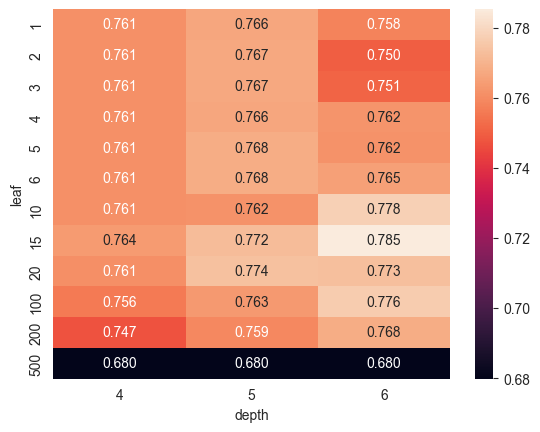

In [70]:
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

<Axes: xlabel='depth', ylabel='leaf'>

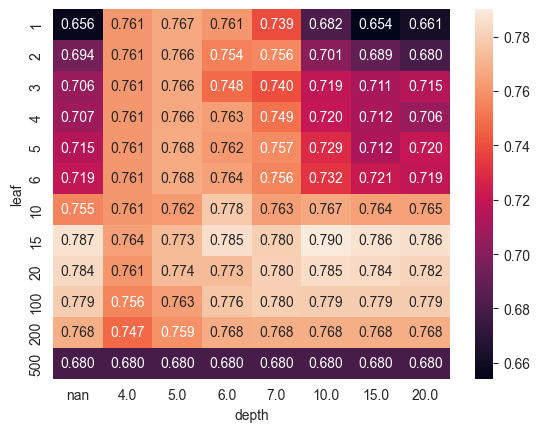

In [71]:
scores = []
for depth in [4, 5, 6, 7, 10, 15, 20, None]:
    for leaf in [1, 2, 3, 4, 5, 6, 10, 15, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf)
        dt.fit(X_train, y_train)
        y_pred = dt.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((depth, leaf, auc))
df_scores = pd.DataFrame(scores, columns=["depth", "leaf", "auc"])
df_scores_pivot = df_scores.pivot(index="leaf", columns=["depth"], values="auc")
df_scores_pivot.round(3)
sns.heatmap(df_scores_pivot, annot=True, fmt=".3f")

In [72]:
# Using the model with best combo
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=15)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [73]:
# Random forest is a process of evaluating the decision made by each binary tree and merging the results together.
# Random - because each of binary tree has different random set of features but same number of features.
# E.g. model g1 has 3 features (time, date and temperature), model g2 has also 3 but different (time, month and temperature) and so on.
# The result of all the trees is calculated as an average
# 1/n * SUM(g1,...,gn)

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [94]:
rf = RandomForestClassifier(n_estimators=10, random_state=1) # 10 models to train, random seed = 1 means estimators will always have same feature set
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [85]:
y_pred = rf.predict_proba(X_val)[:,1]

In [86]:
roc_auc_score(y_val, y_pred)

0.7836211280908673

In [95]:
rf.predict_proba(X_val[[0]])

array([[0.9, 0.1]])

In [96]:
scores = []
for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    scores.append((n, auc))

In [98]:
df_scores = pd.DataFrame(scores, columns=["n_of_estimators", "auc"])

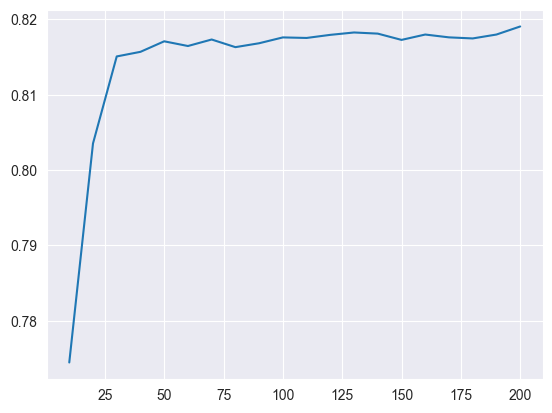

In [101]:
plt.plot(df_scores.n_of_estimators, df_scores.auc)

In [117]:
# Best value for number of estimators is 100 according to graph
n_estimators = 100

In [107]:
# Determining the best max depth value
scores = []
depth_range = [5, 10, 15]
for d in depth_range:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, n, auc))

In [108]:
df_scores = pd.DataFrame(scores, columns=["max_depth", "n_of_estimators", "auc"])
df_scores

,max_depth,n_of_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


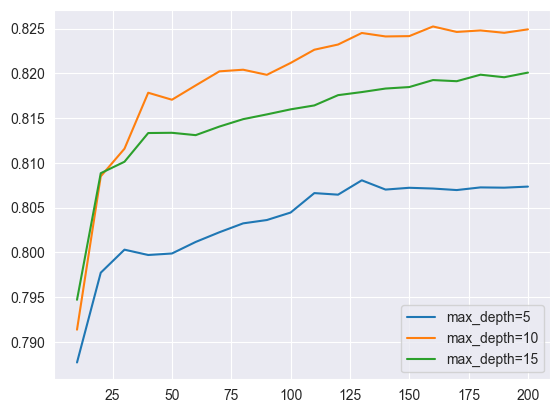

In [110]:
for d in depth_range:
    df_subset = df_scores[df_scores.max_depth == d]
    plt.plot(df_subset.n_of_estimators, df_subset.auc, label = f"max_depth={d}")
plt.legend()

In [112]:
# Best max depth value according to graph
max_depth = 10

In [113]:
# Determining the best leaf count value
scores = []
leaf_count = [1, 3, 5, 10, 50]
for s in leaf_count:
    for n in range(10, 201, 10):
        rf = RandomForestClassifier(n_estimators=n, max_depth=max_depth, random_state=1, min_samples_leaf=s)
        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((s, n, auc))

In [114]:
df_scores = pd.DataFrame(scores, columns=["leaf_count", "n_of_estimators", "auc"])
df_scores

,leaf_count,n_of_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058
...,...,...,...
95,50,160,0.805929
96,50,170,0.805172
97,50,180,0.805324
98,50,190,0.805596


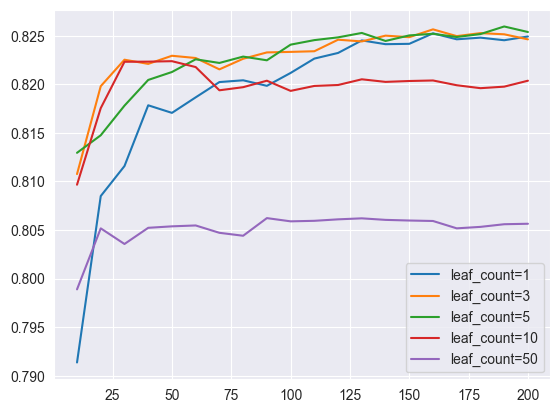

In [115]:
for s in leaf_count:
    df_subset = df_scores[df_scores.leaf_count == s]
    plt.plot(df_subset.n_of_estimators, df_subset.auc, label = f"leaf_count={s}")
plt.legend()

In [121]:
# Best value of min_sample_leaf is 3 according to graph
leaf_count = 3

In [126]:
rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=leaf_count, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_val)[:,1]
auc = roc_auc_score(y_val, y_pred)